# NB03: London Air Quality Data Analysis

**DS105W Mini-Project 1, Data for Data Science (Winter Term 2025/2026)**

<div style="font-family: system-ui; padding: 20px 30px 20px 20px; background-color: #FFFFFF; border-left: 8px solid #ED9255; border-radius: 8px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);max-width:600px;color:#212121;">

**Student Notebook**
- 📅 Date: 23 February 2026
- 👤 Name: Joshua Andrew
- 📛 Candidate Number: 67321
- 🎯 Purpose: Analyse London air pollution data to understand if pollution trends change on weekends compared to weekdays.
- ❓  **Question: Does London's air clean up on weekends?**

</div>

## Overview

This notebook loads the cleaned CSV from NB02 and produces two insights about weekday vs weekend air quality in London. The data was originally collected from the OpenWeather Air Pollution API in NB01 (covering late 2020 to end of 2025), then cleaned and tagged with weekday/weekend labels in NB02.

The two insights address different aspects of the question:

- **Insight 1** looks at which pollutants differ most between weekdays and weekends, using a styled DataFrame.
- **Insight 2** looks at how the hourly NO2 pattern within a day differs between weekdays and weekends, using a seaborn line plot.

## Section 1: Setup

In [1]:
# Note: pandas Styler requires jinja2 
!pip install jinja2
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("✅ Libraries loaded successfully!")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Libraries loaded successfully!


💭 **Personal Reflection Notes:** When I first ran the `.style` cell, I got `AttributeError: The '.style' accessor requires jinja2`. The W05 Lecture notebooks used `.style` without any issues because `jinja2` was pre-installed in Nuvolos. I fixed this locally by running `pip install jinja2` and restarting the kernel. This was a good reminder that environment differences can cause unexpected errors, which is why I listed required packages in NB01's reproducibility section.

In [2]:
# Matplotlib configuration (W05 Lab setup)
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

# Create figures folder if it doesn't exist
os.makedirs("../figures", exist_ok=True)

## Section 2: Load and Explore the Data

Loading the CSV saved in NB02.

In [3]:
df = pd.read_csv("../data/london_air_quality_2020_2025.csv")

print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 44064 rows
Columns: ['date', 'hour', 'dayofweek', 'is_weekend', 'day_type', 'month', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']


,date,hour,dayofweek,is_weekend,day_type,month,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2020-11-27,0,4,False,Weekday,11,2.0,347.14,33.53,41.13,0.01,7.51,18.81,21.35,0.25
1,2020-11-27,1,4,False,Weekday,11,2.0,293.73,11.18,42.16,0.21,7.27,15.68,18.17,0.01
2,2020-11-27,2,4,False,Weekday,11,2.0,277.04,5.64,41.81,0.32,7.33,15.31,17.65,0.01
3,2020-11-27,3,4,False,Weekday,11,2.0,277.04,4.75,41.13,0.40,7.57,15.78,18.02,0.02
4,2020-11-27,4,4,False,Weekday,11,2.0,277.04,4.47,40.44,0.43,7.87,16.73,18.96,0.03


In [4]:
# How much data per group?
print("Day type counts:")
print(df["day_type"].value_counts())

Day type counts:
day_type
Weekday    31486
Weekend    12578
Name: count, dtype: int64


In [5]:
# Quick look at the pollutant distributions
pollutant_cols = ["no2", "pm2_5", "pm10", "co", "o3", "so2", "no", "nh3"]
df[pollutant_cols].describe()

,no2,pm2_5,pm10,co,o3,so2,no,nh3
count,44062.000000,44064.000000,44063.000000,44064.000000,44063.000000,44064.000000,44064.000000,44064.000000
mean,19.313279,6.806871,8.657197,239.485032,51.593570,7.704103,6.764095,0.908936
std,17.035433,9.104027,9.800334,94.309418,30.070263,7.676688,24.869802,1.084641
min,0.690000,0.000000,0.000000,81.200000,0.000000,0.550000,0.000000,0.000000
25%,7.540000,1.910000,2.960000,190.260000,30.760000,3.670000,0.000000,0.320000
50%,13.540000,3.580000,5.490000,230.310000,55.070000,5.720000,0.290000,0.590000
75%,25.700000,7.810000,10.480000,267.030000,72.240000,9.082500,1.600000,1.070000
max,174.110000,115.890000,117.470000,1535.420000,217.440000,188.830000,529.290000,16.720000


💭 **Personal Reflection Notes:**

A few things stand out from the exploration above. There are about 2.5x as many weekday hours (31,486) as weekend hours (12,578), which is expected since there are five weekdays and two weekend days. The weekend group is still large (12,000+ observations), so the group means should be stable.

Looking at `.describe()`, some distributions are quite skewed. NO has a mean of 6.8 but a max of 529, and NO2's standard deviation (17.0) is nearly as large as its mean (19.3). I will use the mean rather than the median for the weekday-weekend comparison because both groups are large and both are affected by spikes in similar ways, so the spikes roughly cancel in the comparison. I also stuck with `.groupby().mean()` since that the research question asks "are pollution levels different on weekdays vs weekends?". The most direct way to answer that is to calculate the average for each group and compare them. The mean allows for analysis with regard to this question by splitting the data into weekday and weekend groups and computing the mean for each.

Other analytical decisions (time period, location, weekend definition, data cleaning) are documented in NB01 and NB02.

## Section 3: Insight 1 -- Which pollutants differ most between weekdays and weekends?

I will group the data by `day_type` and compute the mean for each pollutant, then calculate the percentage change from weekday to weekend. Presenting percentage changes rather than raw means puts all pollutants on the same scale, since their raw concentrations range from 0.9 (NH3) to 241 (CO). This uses the `.groupby().mean()` pattern from the W05 Lecture Section 3 and vectorised arithmetic from the W04 Lecture.

In [6]:
# .groupby('day_type')[columns].mean() gives the average for each group (W05 Lecture Section 3)
cols = ["aqi", "no2", "pm2_5", "pm10", "co", "o3", "so2", "no", "nh3"]
means = df.groupby("day_type")[cols].mean()

# Calculate percentage change: (weekend - weekday) / weekday * 100
# This is vectorised arithmetic on pandas Series (W04 Lecture)
weekday_means = means.loc["Weekday"]
weekend_means = means.loc["Weekend"]
pct_change = ((weekend_means - weekday_means) / weekday_means * 100)

# Build a summary table with all three pieces of information
summary_df = pd.DataFrame({
    "Weekday Mean": weekday_means,
    "Weekend Mean": weekend_means,
    "% Change": pct_change
})

# Sort by % change so the biggest drops appear first (W01 notebook: .sort_values)
summary_df = summary_df.sort_values("% Change")

# Clean up row names for readability
summary_df.index = ["NO", "SO2", "NO2", "PM2.5", "PM10", "CO", "AQI", "NH3", "O3"]

print(summary_df)

       Weekday Mean  Weekend Mean   % Change
NO         7.242823      5.565714 -23.155459
SO2        8.105455      6.699416 -17.346816
NO2       20.068412     17.422896 -13.182490
PM2.5      6.910776      6.546769  -5.267237
PM10       8.769258      8.376687  -4.476673
CO       241.097142    235.449500  -2.342476
AQI        1.652438      1.634521  -1.084309
NH3        0.902203      0.925789   2.614209
O3        50.887562     53.360836   4.860274


In [7]:
# Style using Styler methods from W05 Lecture Section 4
(
    summary_df.style
    .format({"Weekday Mean": "{:.1f}", "Weekend Mean": "{:.1f}", "% Change": "{:+.1f}%"})
    .background_gradient(subset=["% Change"], cmap="RdYlGn", vmin=-25, vmax=25)
    .set_caption(
    "<b>NO drops 23% and NO2 drops 13% on weekends, "
    "but PM and CO barely change and ozone actually rises 5%</b>"
    "<div style='height:15px'></div>"
)
    .set_table_styles([
    {"selector": "caption", "props": [("margin-bottom", "10px")]}
    ])
)

,Weekday Mean,Weekend Mean,% Change
NO,7.2,5.6,-23.2%
SO2,8.1,6.7,-17.3%
NO2,20.1,17.4,-13.2%
PM2.5,6.9,6.5,-5.3%
PM10,8.8,8.4,-4.5%
CO,241.1,235.4,-2.3%
AQI,1.7,1.6,-1.1%
NH3,0.9,0.9,+2.6%
O3,50.9,53.4,+4.9%


💭 **Personal Reflection Notes:**

I used `.groupby('day_type')[cols].mean()` to get the average hourly concentration for each pollutant and the AQI on weekdays vs weekends (W05 Lecture Section 3). Since each row is one hour, this gives the average concentration across all weekday hours (and separately all weekend hours). This is not quite the same as averaging daily means, because days with data gaps get slightly less weight, but with ~44,000 hours and only a handful of gaps (as checked in NB02), the difference is negligible. I renamed the rows since raw names like `pm2_5` are hard to read. I included AQI because NB02 extracted it and it summarises overall air quality in a single number. 

I chose to show percentage changes rather than just raw means because the pollutants have very different scales. CO averages around 240 while NH3 is around 0.9, so comparing raw numbers side by side does not show which pollutant is most affected by the weekend. The percentage change puts them on the same scale and lets you see the effect size at a glance.

I built the summary table by extracting the Weekday and Weekend rows from the groupby result using `.loc["Weekday"]` and `.loc["Weekend"]`, then doing vectorised subtraction and division to get the percentage change (same kind of vectorised arithmetic as `temps_array * 9/5 + 32` from the W04 Lecture). I wrapped the result in `pd.DataFrame()` (W04/W05 Lecture) and sorted with `.sort_values()` so the biggest drops appear first. Sorting makes the three-group pattern immediately visible without the reader having to scan all nine rows.

For the Styler, I applied `.background_gradient()` only to the `% Change` column using `subset=["% Change"]` so the colour scale reflects the direction and size of each change. I used `cmap="RdYlGn"` (red-yellow-green) so that decreases appear green (cleaner air on weekends) and increases appear red. I also used `"{:+.1f}%"` in `.format()` so that negative changes show a minus sign and positive changes show a plus sign. These Styler methods are from the W05 Lecture Section 4. The W05 Lecture slides specifically say Styler formatting can be done using documentation or AI tools since so I checked the column-specific `subset` parameter in the [pandas Styler docs](https://pandas.pydata.org/docs/user_guide/style.html). I also set vmin=-25, vmax=25 to center the colour scale at zero, so that all negative changes appear red and all positive changes appear green. Without this, small negative values like -2% were showing as green because the default scale stretches from the minimum to the maximum value in the data. I found this in the same pandas Styler docs.

I also used `.set_table_styles()` to add spacing between the caption and the table headers, since by default the caption was clipping into the column names. This is another Styler formatting method from the pandas Styler docs.

***Note: The background gradient colour change does not render in GitHub for some reason and after troubleshooting, Claude informed me the colours don't render because GitHub's notebook viewer "strips CSS styling for security reasons". I cannot, for the life of me, figure out how to fix this so I apologise for this beforehand 😊. The table title also keeps clipping into the actual table and despite many Claude engineered solutions I cannot seem to rectify it to show nicely in GitHub short of making a markdown cell above the table as a title. I thought that might look distracting so that is why the title is the way it is...***

**What the numbers show:** The pollutants split into three groups. NO (-23%), SO2 (-17%), and NO2 (-13%) drop substantially on weekends, which makes sense as all three are strongly linked to vehicle combustion. PM2.5 (-5%), PM10 (-4%), and CO (-2%) barely change, suggesting these come from sources other than commuter traffic (heating, construction, long-range transport). Ozone (+5%) and NH3 (+3%) actually increase slightly. The ozone rise is a known atmospheric chemistry effect: NO from vehicle exhaust normally destroys O3, so less traffic on weekends means less O3 gets removed. I looked this up and found it is called the "weekend ozone effect." This effect has been observed in cities worldwide. ***(see for example [Blanchard and Tanenbaum, 2003](https://www.tandfonline.com/doi/pdf/10.1080/10473289.2003.10466222)).***

The most revealing number is the AQI. Despite the large individual pollutant drops, the overall AQI barely shifts: 1.65 weekday vs 1.63 weekend, about 1%. On OpenWeather's scale (1=Good, 2=Fair, 3=Moderate, 4=Poor, 5=Very Poor), both sit in the "Good" band. Individual pollutants do get cleaner on weekends, but the overall air quality *classification* does not change because the ozone increase offsets the traffic pollutant gains.

**Limitation:** The data includes 2020-2021 when COVID lockdowns reduced weekday traffic. I kept the full dataset because the brief asks about London's air generally and filtering would remove roughly a third of the data. The lockdown periods may slightly understate the normal weekday-weekend gap.

**Decisions I made here:**
The brief asked whether to use OpenWeather's index levels or custom thresholds. I chose to use OpenWeather's built-in AQI (1-5 scale) as it was already in the data from NB02, and defining custom thresholds would have required citing government air quality standards (e.g. UK DEFRA or WHO guidelines) for each pollutant individually. The AQI gives a single summary number that already accounts for all pollutants, which made it useful for seeing whether the overall classification changes between weekdays and weekends (it does not: both are in the "Good" band).


## Section 4: Insight 2 -- When during the day does the weekday-weekend NO2 gap appear?

NO2 showed a clear weekday-weekend difference in Insight 1 (13% overall drop). I now want to see whether this drop is spread evenly through the day or concentrated at specific hours. I will use a line plot following the `plot_df` workflow from the W05 Lab: prepare, inspect, plot, title, save.

In [8]:
# Step 1: Prepare plot_df
# Group by day_type and hour, then get the mean NO2 for each combination
plot_df = df.groupby(["day_type", "hour"])["no2"].mean().reset_index()

# Step 2: Inspect
print(f"Shape: {plot_df.shape}")
print(plot_df.head(10))

Shape: (48, 3)
  day_type  hour        no2
0  Weekday     0  20.855061
1  Weekday     1  18.497691
2  Weekday     2  16.995854
3  Weekday     3  15.999802
4  Weekday     4  15.369687
5  Weekday     5  15.519535
6  Weekday     6  17.614215
7  Weekday     7  21.612759
8  Weekday     8  23.949482
9  Weekday     9  23.453758


In [9]:
# Split into weekday and weekend for separate plotting
# Using boolean filtering (W05 Lecture: df[df['temperature'] > 25])
weekday_df = plot_df[plot_df["day_type"] == "Weekday"]
weekend_df = plot_df[plot_df["day_type"] == "Weekend"]

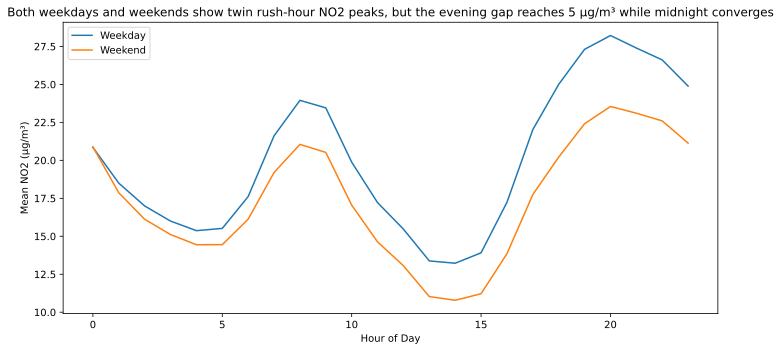

✅ Saved to figures/


In [10]:
# Plot using sns.lineplot (W05 Lab seaborn quick reference: lineplot for trends over time)
plt.figure(figsize=(10, 5))

# errorbar=None removes the default CI band (see reflection below)
sns.lineplot(data=weekday_df, x="hour", y="no2", errorbar=None)
sns.lineplot(data=weekend_df, x="hour", y="no2", errorbar=None)

# plt.legend() needed to label two lines (see reflection below)
plt.legend(["Weekday", "Weekend"])

# Narrative title: states the finding with specific numbers
plt.title("Both weekdays and weekends show twin rush-hour NO2 peaks, "
          "but the evening gap reaches 5 µg/m³ while midnight converges")
plt.xlabel("Hour of Day")
plt.ylabel("Mean NO2 (µg/m³)")

# Save before plt.show() (W05 Lab Task 02)
plt.tight_layout()
plt.savefig("../figures/no2-hourly-weekday-vs-weekend.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/no2-hourly-weekday-vs-weekend.svg", bbox_inches="tight")
plt.show()

print("✅ Saved to figures/")

💭 **Personal Reflection Notes:**

I chose NO2 for the hourly breakdown rather than NO (which had the largest percentage drop at 23%) for two reasons. First, NO2 is the pollutant most commonly reported in UK air quality monitoring, so it is more familiar to readers. Second, NO has very low absolute concentrations (mean ~7 µg/m³ with many hours at 0.0), which would make the line chart noisy. NO2's higher baseline (~20 µg/m³) produces cleaner patterns.

I picked a line plot (`sns.lineplot`) because the W05 Lab seaborn quick reference says line plots are to "show trends over time," and hour-of-day is a continuous variable. A bar chart would also work but 24 bars per group would be cluttered.

The `plot_df` was built using `.groupby(['day_type', 'hour'])['no2'].mean().reset_index()`, extending the `.groupby('year')['temp'].mean()` pattern from the W05 Lecture to two grouping columns. Each hour-bucket has ~1,300 readings per day type, so the same caveat as Insight 1 applies (days with missing hours get slightly less weight), but with that many observations per bucket the effect is negligible. The `.reset_index()` turns the result back into a flat DataFrame for seaborn. I split it using boolean filtering (`plot_df[plot_df['day_type'] == 'Weekday']`) and plotted two separate lines.

I used two parameters not shown in class, both needed because the W05 Lab only demonstrated single-line plots. First, `errorbar=None` in `sns.lineplot()`. By default seaborn draws a confidence interval band, but since my `plot_df` has one pre-aggregated mean per hour, there is no sample to estimate a CI from so the band is meaningless. It also caused `plt.legend()` to mislabel the lines. I found this in the [seaborn lineplot docs](https://seaborn.pydata.org/generated/seaborn.lineplot.html) and tested by running with and without. Second, `plt.legend()` to label the two lines, found in the [matplotlib docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html).

**What the plot shows:** Both weekdays and weekends follow the same double-peak shape, with a morning rise around 7-9am and a larger evening peak around 7-8pm, with a dip in the early afternoon. This matches the pattern of London commuter traffic. The weekday line sits above the weekend line at almost every hour, but the gap is not constant. It is largest in the evening hours (about 4-5 µg/m³ around 7-8pm) and smallest around midnight (at hour 0 the two lines essentially converge). The morning rush-hour gap is smaller than I expected, only about 3 µg/m³ at 8am, which suggests that the evening commute has a bigger effect on NO2 than the morning one.

This adds nuance to Insight 1, that the overall 13% NO2 drop is not spread evenly across the day but is driven mainly by the evening commute period.

## Section 5: Conclusion

The answer to "does London's air clean up on weekends?" depends on how you measure it. Individual traffic pollutants like NO (-23%), SO2 (-17%), and NO2 (-13%) show clear drops. However, the overall AQI barely moves (1.65 weekday vs 1.63 weekend), staying in the "Good" band on both days, because ozone rises on weekends and partly offsets the improvements.

Insight 2 adds that the NO2 gap is not uniform across the day. Both weekdays and weekends follow the same double-peak commuter pattern (morning and evening), but the gap between them is largest in the evening rush (~5 µg/m³ around 7-8pm) and nearly vanishes around midnight. The evening commute drives more of the weekday-weekend difference than the morning one. This could suggest that London's traffic-reduction policies (like ULEZ) may have a bigger impact on NO2 than on PM2.5, which would require targeting non-traffic sources.

There is a caveat as the dataset spans late 2020 to 2025, which includes COVID lockdowns when traffic dropped on weekdays too. This could make the weekday-weekend gap appear smaller than it normally would be.

💭 **Personal Reflection Notes:**

I combined one styled DataFrame with one seaborn line plot because each answers a different part of the question. The table compares all eight pollutants and the AQI side by side, showing *which* metrics change on weekends and revealing that the overall AQI does not actually shift despite individual improvements. The line chart shows *when* during the day the NO2 gap appears, revealing that the evening commute drives more of the difference than the morning.

If I had more time, I would filter out the COVID lockdown months and re-run both insights to check whether the patterns hold under normal traffic conditions. I would also break down Insight 1 by season, since the weekday-weekend gap might change with the seasons as more or less people drive to work and school.